<a href="https://colab.research.google.com/github/Somrat390/Deep-Learning/blob/main/Pytorch_Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task1

In [ ]:
import torch

In [ ]:
scaler = torch.tensor([9])
print(f" shape : {scaler.shape}")
print(f"Dimention: {scaler.ndim}")
scaler.dtype


 shape : torch.Size([1])
Dimention: 1


torch.int64

In [ ]:
vector = torch.tensor([3,4,5,6])
print(f" shape : {vector.shape}")
print(f"Dimention: {vector.ndim}")
vector.dtype

 shape : torch.Size([4])
Dimention: 1


torch.int64

In [ ]:
matrix =torch.tensor([[[1,2,3],
          [4,5,6],
          [7,8,9]]])
print(f" shape : {matrix.shape}")
print(f"Dimention: {matrix.ndim}")
matrix.dtype

 shape : torch.Size([1, 3, 3])
Dimention: 3


torch.int64

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

x = torch.tensor([[1,2,3]])

x = x.to(device)
x.device

device(type='cpu')

# Pytorch Workflow
* Get the data and convert the data into tensor
* Build or pick a pretrained model ----> pick a loss fucntion & Optiminzer --> Build a training loop ---> Build or pick a pretrained model

* fit the model to the data and make a prediction
* Evaluate the model
* Improve through Experience
* Save and Reload trained model

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.11.0+cu128'

In [2]:
weight = 0.7
bias = 0.3

start = 0
end =1
step = 0.02

X = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight * X + bias

X , y

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800],
         [0.2000],
         [0.2200],
         [0.2400],
         [0.2600],
         [0.2800],
         [0.3000],
         [0.3200],
         [0.3400],
         [0.3600],
         [0.3800],
         [0.4000],
         [0.4200],
         [0.4400],
         [0.4600],
         [0.4800],
         [0.5000],
         [0.5200],
         [0.5400],
         [0.5600],
         [0.5800],
         [0.6000],
         [0.6200],
         [0.6400],
         [0.6600],
         [0.6800],
         [0.7000],
         [0.7200],
         [0.7400],
         [0.7600],
         [0.7800],
         [0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.3000],
         [0.3140],
         [

In [3]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(X_test), len(y_train), len(y_test)

(40, 10, 40, 10)

In [4]:
def plot_prediction(train_data = X_train,
                    train_label = y_train,
                    test_data = X_test,
                    test_label = y_test,
                    predictions = None):
  plt.figure(figsize=(10,7))

  plt.scatter(train_data,train_label,c='b',s=5,label="training data")

  plt.scatter(test_data,test_label,c='g',s=8,label="test data")

  if predictions is not None:
    plt.scatter(test_data,predictions,c='r',s=8,label="predicted data")

  plt.legend()
  plt.show()



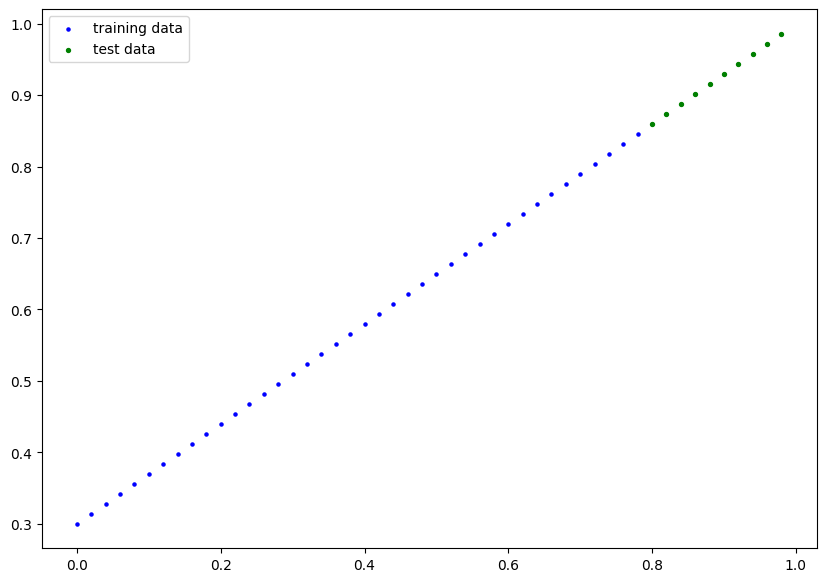

In [5]:
plot_prediction()

In [6]:
class LinearRegression_Model(nn.Module):
  def __init__(self) -> None:
    super().__init__()

    self.weight = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)

    self.bias = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)

  def forward(self, x:torch.tensor) -> torch.tensor:
      return self.weight*x +  self.bias


In [7]:
torch.manual_seed(seed=40)

model0 = LinearRegression_Model()

list(model0.parameters())


[Parameter containing:
 tensor([0.9307], requires_grad=True),
 Parameter containing:
 tensor([-0.3482], requires_grad=True)]

In [8]:
model0.state_dict()

OrderedDict([('weight', tensor([0.9307])), ('bias', tensor([-0.3482]))])

In [9]:
with torch.inference_mode():
  y_pred = model0(X_test)



In [10]:
print(f"Number of testing samples: {len(X_test)}")
print(f"Number of predictions made: {len(y_pred)}")
print(f"Predicted values:\n{y_pred}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[0.3964],
        [0.4150],
        [0.4336],
        [0.4522],
        [0.4709],
        [0.4895],
        [0.5081],
        [0.5267],
        [0.5453],
        [0.5639]])


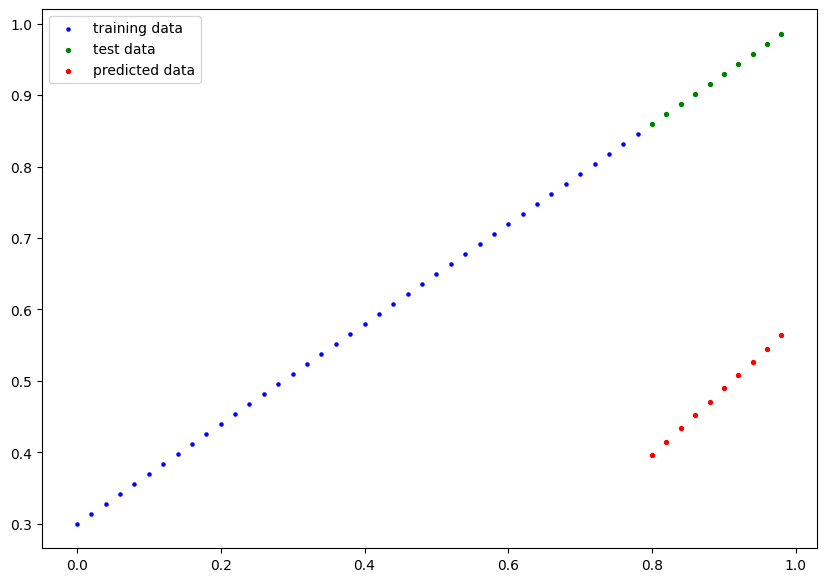

In [11]:
plot_prediction(predictions=y_pred)

In [12]:
y_test - y_pred

tensor([[0.4636],
        [0.4590],
        [0.4544],
        [0.4498],
        [0.4451],
        [0.4405],
        [0.4359],
        [0.4313],
        [0.4267],
        [0.4221]])

In [13]:
loss_function = nn.L1Loss()

optimizer = torch.optim.SGD(params=model0.parameters(), lr=0.01)

In [14]:
torch.manual_seed(seed = 42)

epochs = 500

train_loss_values = []
test_loss_values = []
epoch_count = []

for epoc in range(epochs):

  model0.train()

  y_pred = model0(X_train)

  loss = loss_function(y_pred, y_train)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model0.eval()

  with torch.inference_mode():
    test_pred = model0(X_test)

  test_loss = loss_function(test_pred, y_test.type(torch.float))

  if epoc % 10 == 0:
     epoch_count.append(epoc)
     train_loss_values.append(loss.detach().numpy())
     test_loss_values.append(test_loss.detach().numpy())
     print(f"Epoch: {epoc} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")




Epoch: 0 | MAE Train Loss: 0.5581926107406616 | MAE Test Loss: 0.4293646216392517 
Epoch: 10 | MAE Train Loss: 0.4429827630519867 | MAE Test Loss: 0.29465484619140625 
Epoch: 20 | MAE Train Loss: 0.3277726471424103 | MAE Test Loss: 0.15994469821453094 
Epoch: 30 | MAE Train Loss: 0.2125624716281891 | MAE Test Loss: 0.026516448706388474 
Epoch: 40 | MAE Train Loss: 0.11256273835897446 | MAE Test Loss: 0.09451305121183395 
Epoch: 50 | MAE Train Loss: 0.08638741075992584 | MAE Test Loss: 0.14412939548492432 
Epoch: 60 | MAE Train Loss: 0.07864297181367874 | MAE Test Loss: 0.16114583611488342 
Epoch: 70 | MAE Train Loss: 0.07428815215826035 | MAE Test Loss: 0.16465787589550018 
Epoch: 80 | MAE Train Loss: 0.07073372602462769 | MAE Test Loss: 0.16050679981708527 
Epoch: 90 | MAE Train Loss: 0.06720560044050217 | MAE Test Loss: 0.15635566413402557 
Epoch: 100 | MAE Train Loss: 0.06376437842845917 | MAE Test Loss: 0.14808347821235657 
Epoch: 110 | MAE Train Loss: 0.06033219024538994 | MAE Tes

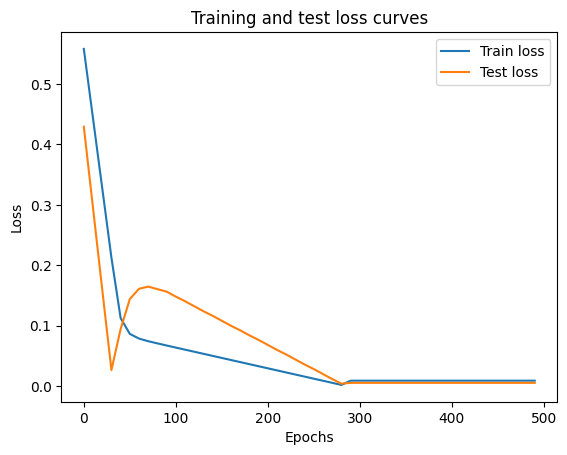

In [15]:
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [16]:
print("The model learned the following values for weights and bias:")
print(model0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: {weight}, bias: {bias}")

The model learned the following values for weights and bias:
OrderedDict({'weight': tensor([0.7018]), 'bias': tensor([0.2903])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


In [17]:
model0.eval()

with torch.inference_mode():
 y_pred = model0(X_test)

y_pred

tensor([[0.8517],
        [0.8658],
        [0.8798],
        [0.8938],
        [0.9079],
        [0.9219],
        [0.9359],
        [0.9500],
        [0.9640],
        [0.9780]])

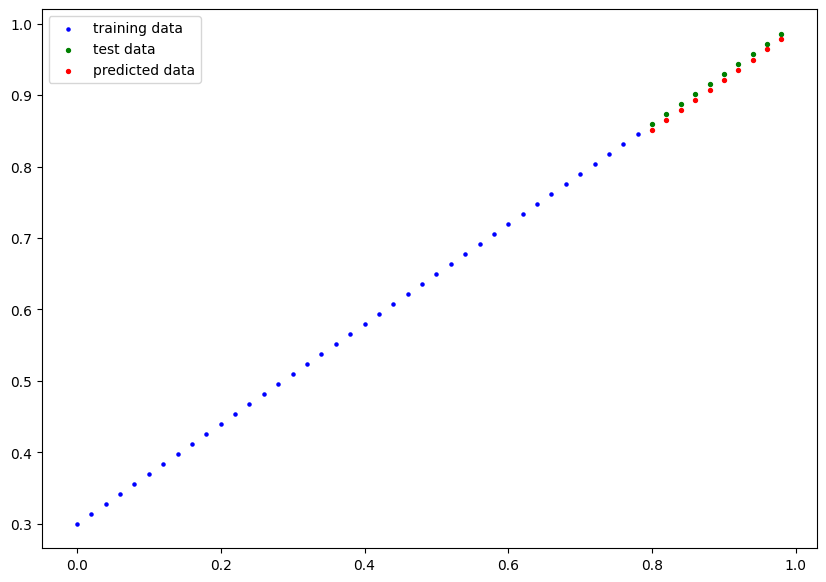

In [18]:
plot_prediction(predictions=y_pred)

In [22]:
from pathlib import Path

Model_Path = Path("models")
Model_Path.mkdir(parents=True,exist_ok=True)

Model_Name  = "Pytorch_workflow.pth"
Model_Saved_Path = Model_Path / Model_Name

torch.save(obj=model0.state_dict(), f=Model_Saved_Path)

In [23]:
!ls -l models/Pytorch_workflow.pth

-rw-r--r-- 1 root root 1965 Jul 18 12:46 models/Pytorch_workflow.pth


In [24]:
loaded_Model0 = LinearRegression_Model()

loaded_Model0.load_state_dict(torch.load('models/Pytorch_workflow.pth'))

<All keys matched successfully>

In [25]:
loaded_Model0.eval()

with torch.inference_mode():
  loaded_pred = loaded_Model0(X_test)

In [26]:
y_pred == loaded_pred

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])